In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
CHECKPOINT_PATH = Path("/content/drive/MyDrive/checkpoints/generator_epoch50.pth")

if not CHECKPOINT_PATH.exists():
    print("⚠️ Checkpoint not found at that path — locate your .pth file and update CHECKPOINT_PATH.")
else:
    print("Found checkpoint:", CHECKPOINT_PATH)

Found checkpoint: /content/drive/MyDrive/checkpoints/generator_epoch50.pth


In [3]:
import zipfile

INPUT_ZIP = Path("/content/drive/MyDrive/input_images.zip")
TARGET_ZIP = Path("/content/drive/MyDrive/target_images.zip")

INPUT_DIR = Path("/content/input_images")
TARGET_DIR = Path("/content/target_images")

for zip_path, out_dir in [(INPUT_ZIP, INPUT_DIR), (TARGET_ZIP, TARGET_DIR)]:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

print("Input files:", len(list(INPUT_DIR.rglob("*.png"))))
print("Target files:", len(list(TARGET_DIR.rglob("*.png"))))

Input files: 6000
Target files: 6000


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 256
VAL_SPLIT = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class FingerprintPairDataset(Dataset):
    def __init__(self, input_dir, target_dir, img_size=256):
        self.input_dir = Path(input_dir)
        self.target_dir = Path(target_dir)
        input_files = {p.name for p in self.input_dir.glob("*.png")}
        target_files = {p.name for p in self.target_dir.glob("*.png")}
        self.filenames = sorted(input_files & target_files)
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        inp = Image.open(self.input_dir / fname).convert("L")
        tgt = Image.open(self.target_dir / fname).convert("L")
        return self.transform(inp), self.transform(tgt)

full_dataset = FingerprintPairDataset(INPUT_DIR, TARGET_DIR, IMG_SIZE)
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
_, val_ds = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=True, num_workers=2)
print("Val pairs:", len(val_ds))

Using device: cuda
Val pairs: 600


In [5]:
class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat([x, skip], dim=1)


class GeneratorUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.down1 = UNetDown(in_ch, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_ch, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6); d8 = self.down8(d7)
        u1 = self.up1(d8, d7); u2 = self.up2(u1, d6); u3 = self.up3(u2, d5); u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3); u6 = self.up6(u5, d2); u7 = self.up7(u6, d1)
        return self.final(u7)

generator = GeneratorUNet().to(device)
generator.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
generator.eval()
print("Loaded generator weights from:", CHECKPOINT_PATH)

Loaded generator weights from: /content/drive/MyDrive/checkpoints/generator_epoch50.pth


In [6]:
!apt-get -qq install -y maven > /dev/null

import os
os.makedirs("/content/mvn_scratch", exist_ok=True)

pom_xml = """<?xml version="1.0" encoding="UTF-8"?>
<project xmlns="http://maven.apache.org/POM/4.0.0">
  <modelVersion>4.0.0</modelVersion>
  <groupId>gafis</groupId>
  <artifactId>sourceafis-fetch</artifactId>
  <version>1.0</version>
  <dependencies>
    <dependency>
      <groupId>com.machinezoo.sourceafis</groupId>
      <artifactId>sourceafis</artifactId>
      <version>3.18.1</version>
    </dependency>
  </dependencies>
</project>
"""
with open("/content/mvn_scratch/pom.xml", "w") as f:
    f.write(pom_xml)

Extracting templates from packages: 100%


In [7]:
!cd /content/mvn_scratch && mvn dependency:copy-dependencies -DoutputDirectory=/content/jars/deps

[INFO] Scanning for projects...
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-clean-plugin/2.5/maven-clean-plugin-2.5.pom (3.9 kB at 8.3 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-plugins/22/maven-plugins-22.pom (13 kB at 229 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/maven-parent/21/maven-parent-21.pom (26 kB at 425 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/apache/10/apache-10.pom (15 kB at 308 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-clean-plugin/2.5/maven-clean-plugin-2.5.jar (25 kB at 418 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-resources-plugin/2.6/maven-resources-plugin-2.6.pom (8.1 kB at 176 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/mav

In [8]:
import glob
all_jars = glob.glob("/content/jars/deps/*.jar")
print(f"Found {len(all_jars)} jars:")
for j in sorted(all_jars):
    print(" -", j)

Found 14 jars:
 - /content/jars/deps/closeablescope-1.0.1.jar
 - /content/jars/deps/commons-io-2.15.0.jar
 - /content/jars/deps/fastutil-8.5.12.jar
 - /content/jars/deps/fingerprintio-1.3.1.jar
 - /content/jars/deps/gson-2.10.1.jar
 - /content/jars/deps/jackson-annotations-2.15.3.jar
 - /content/jars/deps/jackson-core-2.15.3.jar
 - /content/jars/deps/jackson-databind-2.15.3.jar
 - /content/jars/deps/jackson-dataformat-cbor-2.15.3.jar
 - /content/jars/deps/jnbis-2.1.2.jar
 - /content/jars/deps/noexception-1.9.1.jar
 - /content/jars/deps/slf4j-api-2.0.9.jar
 - /content/jars/deps/sourceafis-3.18.1.jar
 - /content/jars/deps/stagean-1.3.0.jar


In [9]:
!pip install -q JPype1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 31.1 MB/s eta 0:00:00


In [10]:
import jpype, jpype.imports
if not jpype.isJVMStarted():
    jpype.startJVM(classpath=all_jars)

from com.machinezoo.sourceafis import (
    FingerprintImage, FingerprintImageOptions, FingerprintTemplate, FingerprintMatcher,
)

FP_DPI = 500.0
_image_opts = FingerprintImageOptions().dpi(FP_DPI)

def tensor_to_png_bytes(tensor):
    import io
    img = ((tensor.squeeze().cpu().numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")
    buf = io.BytesIO()
    Image.fromarray(img, mode="L").save(buf, format="PNG")
    return buf.getvalue()

def build_template(tensor):
    try:
        return FingerprintTemplate(FingerprintImage(tensor_to_png_bytes(tensor), _image_opts))
    except Exception:
        return None

def match_score(probe_tmpl, cand_tmpl):
    if probe_tmpl is None or cand_tmpl is None:
        return None
    return float(FingerprintMatcher(probe_tmpl).match(cand_tmpl))

In [12]:
from tqdm.auto import tqdm
import numpy as np

scores_input_vs_target, scores_gen_vs_target = [], []
extraction_failures = {"input": 0, "gen": 0, "target": 0}
MATCH_THRESHOLD = 40

total_images = len(val_ds)

with torch.no_grad():
    with tqdm(total=total_images, desc="Matching", unit="img") as pbar:
        for inp, tgt in val_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            fake = generator(inp)

            for i in range(inp.size(0)):
                tgt_t = build_template(tgt[i])
                inp_t = build_template(inp[i])
                gen_t = build_template(fake[i])

                for name, t in [("target", tgt_t), ("input", inp_t), ("gen", gen_t)]:
                    if t is None:
                        extraction_failures[name] += 1

                s_in = match_score(inp_t, tgt_t)
                s_gen = match_score(gen_t, tgt_t)

                if s_in is not None:
                    scores_input_vs_target.append(s_in)
                if s_gen is not None:
                    scores_gen_vs_target.append(s_gen)

                pbar.update(1)
                pbar.set_postfix({
                    "fails": sum(extraction_failures.values()),
                    "avg_gen": f"{np.mean(scores_gen_vs_target):.1f}" if scores_gen_vs_target else "—"
                })

print("Valid scores — input:", len(scores_input_vs_target), "| gen:", len(scores_gen_vs_target))
print("Extraction failures:", extraction_failures)

Matching:   0%|          | 0/600 [00:00<?, ?img/s]

/tmp/ipykernel_1152/3746928580.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, mode="L").save(buf, format="PNG")


Valid scores — input: 600 | gen: 600
Extraction failures: {'input': 0, 'gen': 0, 'target': 0}


In [14]:
print("n input:", len(scores_input_vs_target))
print("n gen:", len(scores_gen_vs_target))
print("gen std:", np.std(scores_gen_vs_target))

n input: 600
n gen: 600
gen std: 65.82225634662669


Input vs Target — mean 74.04, median 66.16
GAN vs Target   — mean 134.34, median 134.34
Pass rate @ 40: input 65.8% | gen 91.8%


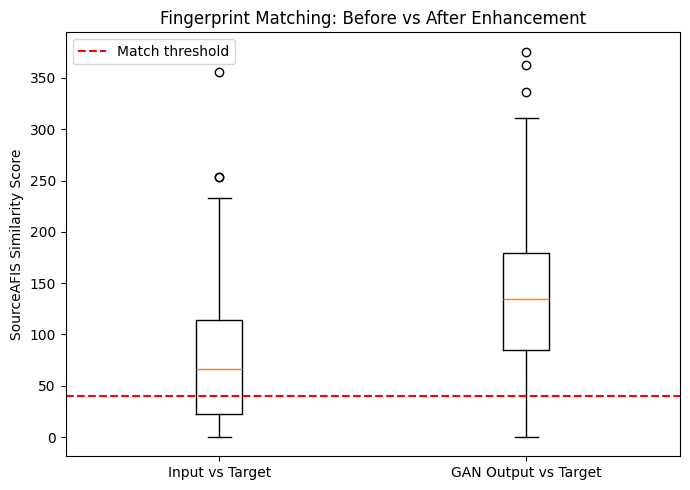

In [13]:
import numpy as np
import matplotlib.pyplot as plt

a, b = np.array(scores_input_vs_target), np.array(scores_gen_vs_target)
print(f"Input vs Target — mean {a.mean():.2f}, median {np.median(a):.2f}")
print(f"GAN vs Target   — mean {b.mean():.2f}, median {np.median(b):.2f}")
print(f"Pass rate @ {MATCH_THRESHOLD}: input {100*(a>=MATCH_THRESHOLD).mean():.1f}% | gen {100*(b>=MATCH_THRESHOLD).mean():.1f}%")

plt.figure(figsize=(7,5))
plt.boxplot([a, b], tick_labels=["Input vs Target", "GAN Output vs Target"])
plt.axhline(MATCH_THRESHOLD, color="red", linestyle="--", label="Match threshold")
plt.ylabel("SourceAFIS Similarity Score")
plt.title("Fingerprint Matching: Before vs After Enhancement")
plt.legend(); plt.tight_layout(); plt.show()